# Task 3 

Using the coins image (water_coins.jpg) since it has clear objects on a plain background.

No threshold value picked manually here, that's the whole point of Otsu ; it figures it
out from the histogram. The 0 in cv2.threshold is just a placeholder, it gets ignored.

For the second experiment I changed the contrast with alpha=1.5 and beta=20 to see if
Otsu still picks a sensible value.

Otsu chose threshold: 162.0
After contrast change, Otsu chose: 204.0


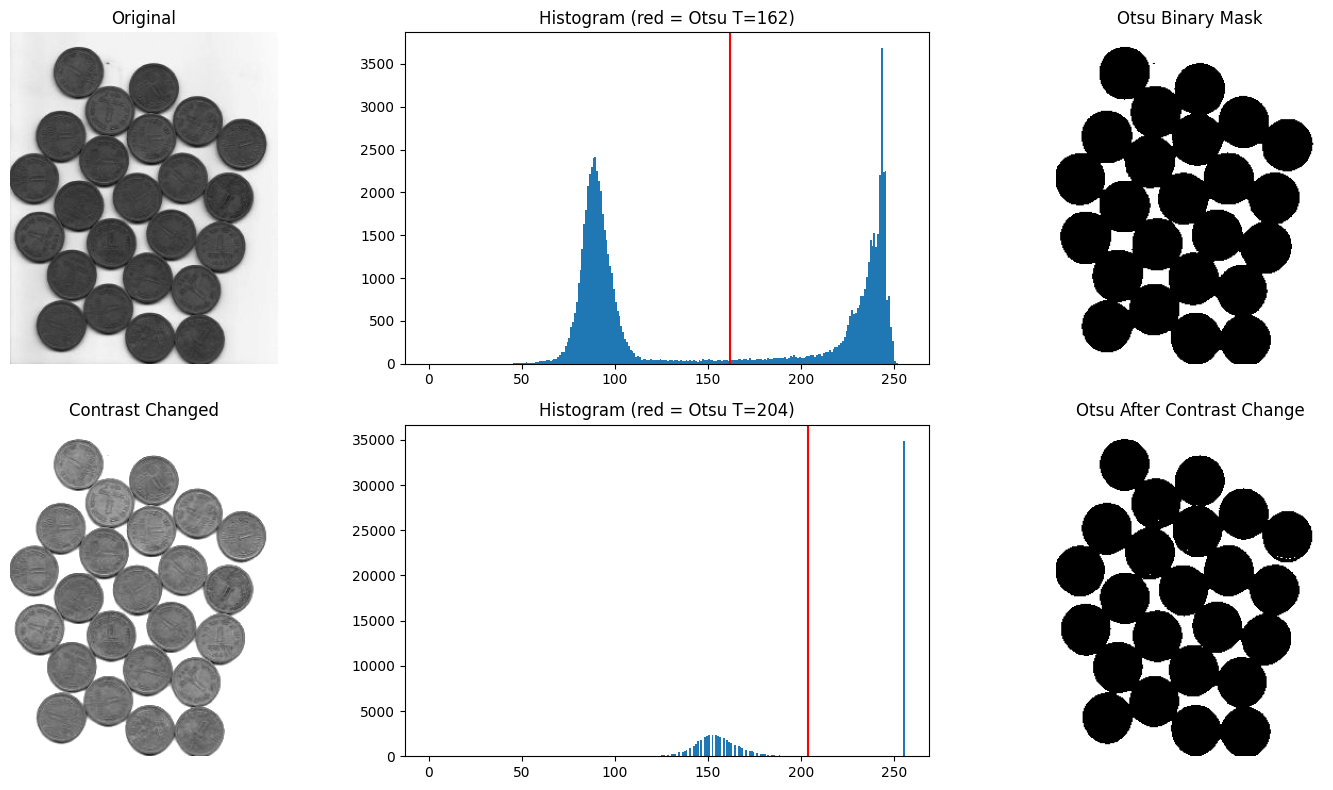

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("water_coins.jpg", cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: water_coins.jpg not found")
else:
    # Otsu picks the threshold automatically (the 0 is ignored)
    t1, otsu1 = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    print("Otsu chose threshold:", t1)

    # Change the contrast a bit and run it again
    changed = cv2.convertScaleAbs(img, alpha=1.5, beta=20)
    t2, otsu2 = cv2.threshold(changed, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    print("After contrast change, Otsu chose:", t2)

    plt.figure(figsize=(16, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(img, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, 3, 2)
    plt.hist(img.ravel(), 256, [0, 256])
    plt.axvline(t1, color="red")
    plt.title("Histogram (red = Otsu T=" + str(int(t1)) + ")")

    plt.subplot(2, 3, 3)
    plt.imshow(otsu1, cmap="gray")
    plt.title("Otsu Binary Mask")
    plt.axis("off")

    plt.subplot(2, 3, 4)
    plt.imshow(changed, cmap="gray")
    plt.title("Contrast Changed")
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.hist(changed.ravel(), 256, [0, 256])
    plt.axvline(t2, color="red")
    plt.title("Histogram (red = Otsu T=" + str(int(t2)) + ")")

    plt.subplot(2, 3, 6)
    plt.imshow(otsu2, cmap="gray")
    plt.title("Otsu After Contrast Change")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

### Results

Threshold Otsu picked on the original: **162**
After the contrast change: **204**

**Looking at the histogram**

The first histogram has two clear humps - the dark coins around 90 and the bright
background around 240 - with an empty gap in between. The red line at 162 lands right
in that gap, which is exactly what Otsu is supposed to do.

In the second histogram the contrast boost pushed most of the background past 255 so it
all piled up into one spike at the end. The image lost some detail but Otsu still found
a reasonable split.

**Why is Otsu useful when you don't know the correct threshold beforehand?**

Because it reads the threshold out of the image's own histogram instead of needing
someone to guess a number. It tries every possible value and keeps the one that
separates the two groups of pixels best. For a factory that's processing hundreds of
images with different lighting, this means the same code works on all of them without
anyone tuning values by hand.

**Comparing the two thresholds**

The two values came out quite different (162 vs 204) but both masks look basically the
same. That shows Otsu adjusts to whatever intensity range the image happens to have
instead of relying on a fixed number.

One limitation though : Otsu assumes the histogram has two clear humps and it still
uses one threshold for the whole image. So it would fail on the uneven lighting document
from Task 1, same as any other global method.